
# Requirement 3 — FTPL primal-dual



## 1. Imports

In [43]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from itertools import product
from scipy.special import betainc
from scipy.optimize import linprog

np.set_printoptions(precision=3, suppress=True)



## 2. Setting


In [44]:

@dataclass
class ProblemConfig:
    T: int
    N: int
    bid_grid: np.ndarray
    values: np.ndarray
    budget: float
    conflict_edges: list[tuple[int, int]]
    max_bid: float = 1.0

    @property
    def rho(self) -> float:
        # Budget moyen fixe. C'est la seule cible utilisée par le dual.
        return self.budget / self.T


def is_independent_set(active_campaigns, conflict_edges) -> bool:
    active = set(active_campaigns)
    return all(not (i in active and j in active) for i, j in conflict_edges)


def enumerate_feasible_actions(bid_grid: np.ndarray, N: int, conflict_edges: list[tuple[int, int]]) -> np.ndarray:
    """Enumerate all discrete bid vectors satisfying campaign conflict constraints."""
    actions = []
    for bids in product(bid_grid, repeat=N):
        bids = np.asarray(bids, dtype=float)
        active = np.flatnonzero(bids > 1e-12)
        if is_independent_set(active, conflict_edges):
            actions.append(bids)

    actions = np.asarray(actions, dtype=float)
    active_counts = (actions > 0).sum(axis=1)
    max_costs = actions.sum(axis=1)
    order = np.lexsort((max_costs, active_counts))
    return actions[order]


def describe_action_space(actions: np.ndarray, config: ProblemConfig) -> pd.DataFrame:
    rows = []
    for k, action in enumerate(actions):
        rows.append({
            "action_id": k,
            "active_campaigns": tuple(np.flatnonzero(action > 0)),
            "bids": tuple(np.round(action, 3)),
            "max_cost": action.sum(),
            "n_active": int((action > 0).sum()),
        })
    return pd.DataFrame(rows)



## 3. Rewards, costs and full feedback


In [45]:

def realized_reward_cost_all(actions: np.ndarray, m_t: np.ndarray, values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Reward and cost of every feasible action against one realized vector of competing bids."""
    wins = (actions > 0) & (actions >= m_t[None, :])
    costs = (actions * wins).sum(axis=1)
    rewards = ((values[None, :] - actions) * wins).sum(axis=1)
    return rewards, costs


def expected_reward_cost_all(
    actions: np.ndarray,
    values: np.ndarray,
    alpha: np.ndarray,
    beta: np.ndarray,
    max_bid: float = 1.0,
) -> tuple[np.ndarray, np.ndarray]:
    """Expected reward/cost of every action under independent Beta competing bids per campaign."""
    x = np.clip(actions / max_bid, 0.0, 1.0)
    win_probs = betainc(alpha[None, :], beta[None, :], x)
    win_probs = np.where(actions > 0, win_probs, 0.0)

    exp_rewards = ((values[None, :] - actions) * win_probs).sum(axis=1)
    exp_costs = (actions * win_probs).sum(axis=1)
    return exp_rewards, exp_costs



## 4. Environment



In [46]:

@dataclass
class BetaPhase:
    start: int
    end: int
    alpha: np.ndarray
    beta: np.ndarray

    @property
    def length(self) -> int:
        return self.end - self.start


class BetaPhaseEnvironment:
    def __init__(self, config: ProblemConfig, phases: list[BetaPhase], seed: int):
        self.config = config
        self.phases = phases
        self.rng = np.random.default_rng(seed)
        self.phase_ids = np.empty(config.T, dtype=int)
        self.competing_bids = np.empty((config.T, config.N), dtype=float)
        self._pre_sample_sequence()

    def _pre_sample_sequence(self):
        for phase_id, phase in enumerate(self.phases):
            L = phase.length
            self.phase_ids[phase.start:phase.end] = phase_id
            self.competing_bids[phase.start:phase.end, :] = (
                self.config.max_bid
                * self.rng.beta(phase.alpha, phase.beta, size=(L, self.config.N))
            )

    def get_round(self, t: int) -> tuple[np.ndarray, int]:
        return self.competing_bids[t], int(self.phase_ids[t])


def make_stochastic_phases(T: int, N: int) -> list[BetaPhase]:
    """One stationary phase."""
    alpha = np.array([2.0, 4.0, 3.0, 5.0, 2.5])[:N]
    beta = np.array([5.0, 3.0, 4.0, 2.5, 6.0])[:N]
    return [BetaPhase(start=0, end=T, alpha=alpha, beta=beta)]


def make_highly_nonstationary_phases(T: int, N: int, n_phases: int = 80, seed: int = 123) -> list[BetaPhase]:
    """Many short phases with abrupt changes in Beta means and concentrations."""
    rng = np.random.default_rng(seed)
    bounds = np.linspace(0, T, n_phases + 1, dtype=int)
    phases = []

    for p in range(n_phases):
        # U-shaped draw for many low/high means, hence abrupt changes in competition intensity.
        means = 0.08 + 0.84 * rng.beta(0.55, 0.55, size=N)
        if p % 2 == 1:
            means = means[::-1]

        concentration = rng.uniform(8.0, 25.0, size=N)
        alpha = np.maximum(0.2, means * concentration)
        beta = np.maximum(0.2, (1.0 - means) * concentration)

        phases.append(BetaPhase(start=int(bounds[p]), end=int(bounds[p + 1]), alpha=alpha, beta=beta))

    return phases



## 5. Benchmark : best distribution in expectation per phase



In [47]:

@dataclass
class PhaseBenchmark:
    p_opt: np.ndarray
    value: float
    expected_cost: float
    exp_rewards: np.ndarray
    exp_costs: np.ndarray


def solve_best_distribution_lp(exp_rewards: np.ndarray, exp_costs: np.ndarray, rho: float) -> tuple[np.ndarray, float, float]:
    """Best randomized action in expectation under expected cost <= rho."""
    K = len(exp_rewards)
    res = linprog(
        c=-exp_rewards,
        A_ub=exp_costs[None, :],
        b_ub=np.array([rho]),
        A_eq=np.ones((1, K)),
        b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * K,
        method="highs",
    )

    if res.success:
        p = np.maximum(res.x, 0.0)
        if p.sum() == 0:
            p[0] = 1.0
        p = p / p.sum()
        return p, float(exp_rewards @ p), float(exp_costs @ p)

    # Fallback, normally unused because the null action is feasible.
    feasible = exp_costs <= rho + 1e-12
    idx = int(np.argmax(np.where(feasible, exp_rewards, -np.inf)))
    p = np.zeros(K)
    p[idx] = 1.0
    return p, float(exp_rewards[idx]), float(exp_costs[idx])


def compute_phase_benchmarks(
    config: ProblemConfig,
    actions: np.ndarray,
    phases: list[BetaPhase],
) -> list[PhaseBenchmark]:
    benchmarks = []
    for phase in phases:
        exp_rewards, exp_costs = expected_reward_cost_all(
            actions=actions,
            values=config.values,
            alpha=phase.alpha,
            beta=phase.beta,
            max_bid=config.max_bid,
        )
        p_opt, value, expected_cost = solve_best_distribution_lp(exp_rewards, exp_costs, config.rho)
        benchmarks.append(
            PhaseBenchmark(
                p_opt=p_opt,
                value=value,
                expected_cost=expected_cost,
                exp_rewards=exp_rewards,
                exp_costs=exp_costs,
            )
        )
    return benchmarks



## 6. Algorithm : Follow the Pertubated Leader (FTPL)


In [48]:

@dataclass
class FTPLPrimalDualConfig:
    eta_primal: float = 0.08
    eta_dual: float = 0.04
    lambda_max: float = 10.0
    discount: float = 1.0
    enforce_hard_budget: bool = True


class FTPLPrimalDualBidder:
    def __init__(
        self,
        actions: np.ndarray,
        config: ProblemConfig,
        learner_config: FTPLPrimalDualConfig,
        seed: int,
    ):
        self.actions = actions
        self.config = config
        self.learner_config = learner_config
        self.rng = np.random.default_rng(seed)

        self.K = len(actions)
        self.cum_rewards = np.zeros(self.K)
        self.cum_costs = np.zeros(self.K)
        self.max_possible_costs = actions.sum(axis=1)

        self.remaining_budget = float(config.budget)
        self.lambda_dual = 0.0

    def choose_action(self) -> int:
        if self.learner_config.enforce_hard_budget:
            feasible = self.max_possible_costs <= self.remaining_budget + 1e-12
        else:
            feasible = np.ones(self.K, dtype=bool)

        if not np.any(feasible):
            return 0  # null action

        perturbation = self.rng.gumbel(loc=0.0, scale=1.0, size=self.K)
        score = (
            self.learner_config.eta_primal
            * (self.cum_rewards - self.lambda_dual * self.cum_costs)
            + perturbation
        )
        score[~feasible] = -np.inf
        return int(np.argmax(score))

    def update(self, rewards_all: np.ndarray, costs_all: np.ndarray, chosen_action: int) -> tuple[float, float]:
        reward_t = float(rewards_all[chosen_action])
        cost_t = float(costs_all[chosen_action])

        self.remaining_budget = max(0.0, self.remaining_budget - cost_t)

        gamma = self.learner_config.discount
        self.cum_rewards = gamma * self.cum_rewards + rewards_all
        self.cum_costs = gamma * self.cum_costs + costs_all

        # Dual update with fixed rho only. No dynamic pacing.
        self.lambda_dual = float(
            np.clip(
                self.lambda_dual + self.learner_config.eta_dual * (cost_t - self.config.rho),
                0.0,
                self.learner_config.lambda_max,
            )
        )

        return reward_t, cost_t



## 7. Realized regret and pseudo-regret



In [49]:

def run_one_seed(
    config: ProblemConfig,
    actions: np.ndarray,
    phases: list[BetaPhase],
    benchmarks: list[PhaseBenchmark],
    learner_config: FTPLPrimalDualConfig,
    seed: int,
) -> dict[str, np.ndarray | float]:
    env = BetaPhaseEnvironment(config, phases, seed=10_000 + seed)
    learner = FTPLPrimalDualBidder(actions, config, learner_config, seed=seed)

    T = config.T
    out = {
        "reward": np.zeros(T),
        "cost": np.zeros(T),
        "lambda": np.zeros(T),
        "remaining_budget": np.zeros(T),
        "regret": np.zeros(T),
        "pseudo_regret": np.zeros(T),
        "oracle_realized_reward": np.zeros(T),
        "oracle_expected_reward": np.zeros(T),
        "learner_expected_reward": np.zeros(T),
    }

    cum_reward = 0.0
    cum_cost = 0.0
    cum_regret = 0.0
    cum_pseudo_regret = 0.0

    for t in range(T):
        action_id = learner.choose_action()
        m_t, phase_id = env.get_round(t)

        rewards_all, costs_all = realized_reward_cost_all(actions, m_t, config.values)
        benchmark = benchmarks[phase_id]

        oracle_realized_reward_t = float(benchmark.p_opt @ rewards_all)
        oracle_expected_reward_t = float(benchmark.value)
        learner_expected_reward_t = float(benchmark.exp_rewards[action_id])

        reward_t, cost_t = learner.update(rewards_all, costs_all, action_id)

        cum_reward += reward_t
        cum_cost += cost_t
        cum_regret += oracle_realized_reward_t - reward_t
        cum_pseudo_regret += oracle_expected_reward_t - learner_expected_reward_t

        out["reward"][t] = cum_reward
        out["cost"][t] = cum_cost
        out["lambda"][t] = learner.lambda_dual
        out["remaining_budget"][t] = learner.remaining_budget
        out["regret"][t] = cum_regret
        out["pseudo_regret"][t] = cum_pseudo_regret
        out["oracle_realized_reward"][t] = oracle_realized_reward_t
        out["oracle_expected_reward"][t] = oracle_expected_reward_t
        out["learner_expected_reward"][t] = learner_expected_reward_t

    out["final_reward"] = float(out["reward"][-1])
    out["final_cost"] = float(out["cost"][-1])
    out["final_regret"] = float(out["regret"][-1])
    out["final_pseudo_regret"] = float(out["pseudo_regret"][-1])
    out["final_lambda"] = float(out["lambda"][-1])
    return out


def run_experiment(
    scenario_name: str,
    config: ProblemConfig,
    phases: list[BetaPhase],
    learner_config: FTPLPrimalDualConfig,
    n_runs: int = 20,
    seed0: int = 0,
) -> tuple[list[dict], np.ndarray, list[PhaseBenchmark]]:
    actions = enumerate_feasible_actions(config.bid_grid, config.N, config.conflict_edges)
    benchmarks = compute_phase_benchmarks(config, actions, phases)

    print(f"{scenario_name}: {len(actions)} feasible actions, {len(phases)} phase(s), rho={config.rho:.3f}")
    print(f"Benchmark expected cost range: {[round(b.expected_cost, 3) for b in benchmarks[:5]]} ...")

    runs = []
    for k in range(n_runs):
        runs.append(
            run_one_seed(
                config=config,
                actions=actions,
                phases=phases,
                benchmarks=benchmarks,
                learner_config=learner_config,
                seed=seed0 + k,
            )
        )
    return runs, actions, benchmarks


## 8. Confidence intervals for the curves

In [50]:

def mean_ci(runs: list[dict], key: str) -> tuple[np.ndarray, np.ndarray]:
    values = np.stack([r[key] for r in runs], axis=0)
    mean = values.mean(axis=0)
    if len(runs) <= 1:
        ci = np.zeros_like(mean)
    else:
        ci = 1.96 * values.std(axis=0, ddof=1) / np.sqrt(len(runs))
    return mean, ci


def plot_mean_ci(runs: list[dict], key: str, title: str, ylabel: str):
    mean, ci = mean_ci(runs, key)
    x = np.arange(1, len(mean) + 1)

    plt.figure(figsize=(9, 4.5))
    plt.plot(x, mean, label="mean")
    plt.fill_between(x, mean - ci, mean + ci, alpha=0.2, label="95% CI = 1.96 s/sqrt(n)")
    plt.xlabel("Round")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def summarize_final_metrics(runs: list[dict], config: ProblemConfig, scenario: str) -> pd.DataFrame:
    rows = []
    for r in runs:
        rows.append({
            "scenario": scenario,
            "final_reward": r["final_reward"],
            "final_cost": r["final_cost"],
            "budget_used_%": 100.0 * r["final_cost"] / config.budget,
            "final_regret": r["final_regret"],
            "final_pseudo_regret": r["final_pseudo_regret"],
            "final_lambda": r["final_lambda"],
        })
    df = pd.DataFrame(rows)
    summary = df.drop(columns=["scenario"]).agg(["mean", "std"])
    summary.loc["ci_95_halfwidth"] = 1.96 * df.drop(columns=["scenario"]).std(ddof=1) / np.sqrt(len(df))
    summary.insert(0, "scenario", scenario)
    return summary



## 9. Parameters for the experiment


In [51]:

T = 6000
N = 5

bid_grid = np.array([0.0, 0.15, 0.30, 0.45, 0.60, 0.75, 0.90])
values = np.array([1.10, 1.30, 1.05, 1.40, 1.20])

# Campaign conflict graph: cycle C5.
conflict_edges = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 0)]

budget = 0.4 * T
config = ProblemConfig(
    T=T,
    N=N,
    bid_grid=bid_grid,
    values=values,
    budget=budget,
    conflict_edges=conflict_edges,
)

actions = enumerate_feasible_actions(config.bid_grid, config.N, config.conflict_edges)
print(f"Number of feasible actions with campaign conflicts: {len(actions)}")
print(f"Budget B={config.budget:.1f}, rho=B/T={config.rho:.3f}")

describe_action_space(actions, config).head(12)


Number of feasible actions with campaign conflicts: 211
Budget B=2400.0, rho=B/T=0.400


,action_id,active_campaigns,bids,max_cost,n_active
0,0,(),"(0.0, 0.0, 0.0, 0.0, 0.0)",0.00,0
1,1,"(4,)","(0.0, 0.0, 0.0, 0.0, 0.15)",0.15,1
2,2,"(3,)","(0.0, 0.0, 0.0, 0.15, 0.0)",0.15,1
3,3,"(2,)","(0.0, 0.0, 0.15, 0.0, 0.0)",0.15,1
4,4,"(1,)","(0.0, 0.15, 0.0, 0.0, 0.0)",0.15,1
5,5,"(0,)","(0.15, 0.0, 0.0, 0.0, 0.0)",0.15,1
6,6,"(4,)","(0.0, 0.0, 0.0, 0.0, 0.3)",0.30,1
7,7,"(3,)","(0.0, 0.0, 0.0, 0.3, 0.0)",0.30,1
8,8,"(2,)","(0.0, 0.0, 0.3, 0.0, 0.0)",0.30,1
9,9,"(1,)","(0.0, 0.3, 0.0, 0.0, 0.0)",0.30,1


## 10. Stochastic test : only one phase

In [52]:

N_RUNS = 20

stochastic_phases = make_stochastic_phases(T=config.T, N=config.N)

stochastic_learner_cfg = FTPLPrimalDualConfig(
    eta_primal=0.08,
    eta_dual=0.04,
    lambda_max=10.0,
    discount=1.0,
    enforce_hard_budget=False,
)

stochastic_runs, stochastic_actions, stochastic_benchmarks = run_experiment(
    scenario_name="stochastic",
    config=config,
    phases=stochastic_phases,
    learner_config=stochastic_learner_cfg,
    n_runs=N_RUNS,
    seed0=0,
)

summarize_final_metrics(stochastic_runs, config, scenario="stochastic")


stochastic: 211 feasible actions, 1 phase(s), rho=0.400
Benchmark expected cost range: [0.4] ...


,scenario,final_reward,final_cost,budget_used_%,final_regret,final_pseudo_regret,final_lambda
mean,stochastic,4868.735000,2418.967500,100.790312,60.541354,60.740820,0.765700
std,stochastic,31.900702,1.206373,0.050266,17.507250,14.218301,0.044287
ci_95_halfwidth,stochastic,13.981099,0.528716,0.022030,7.672890,6.231445,0.019410


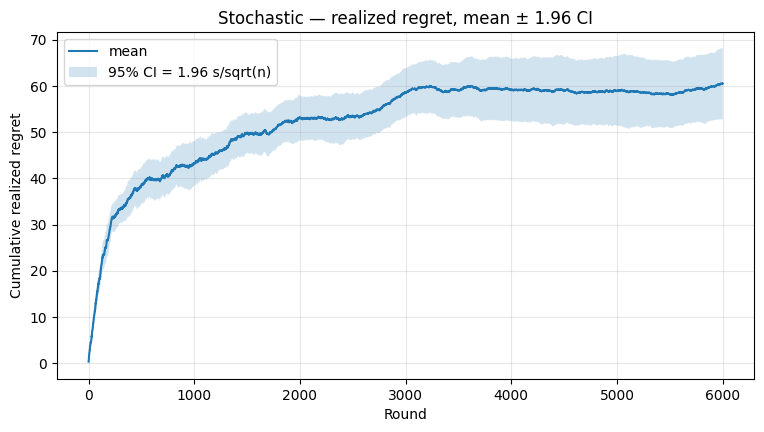

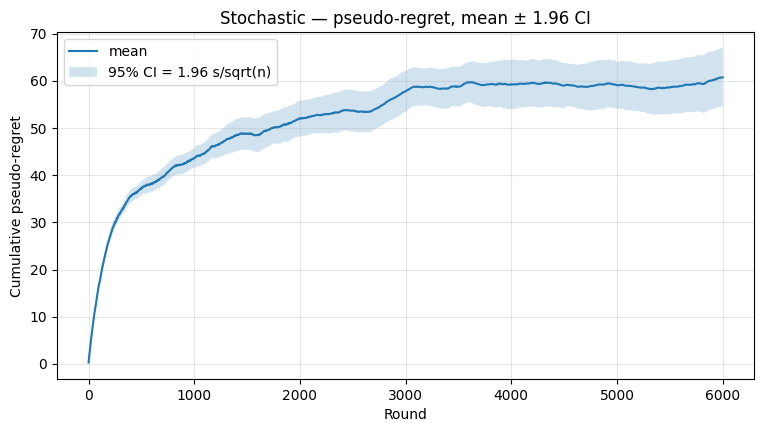

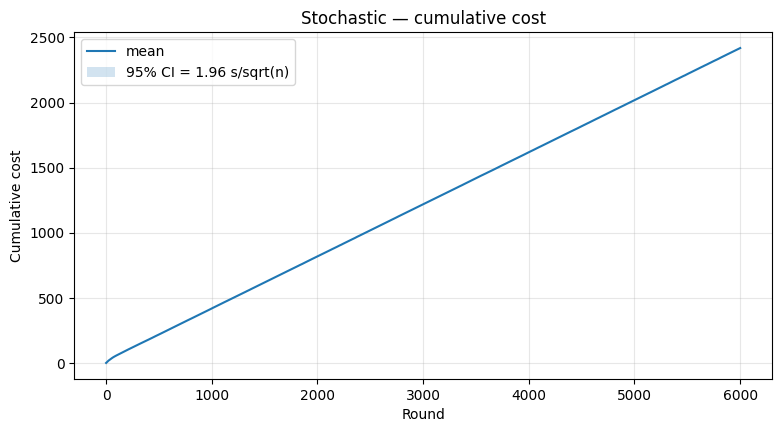

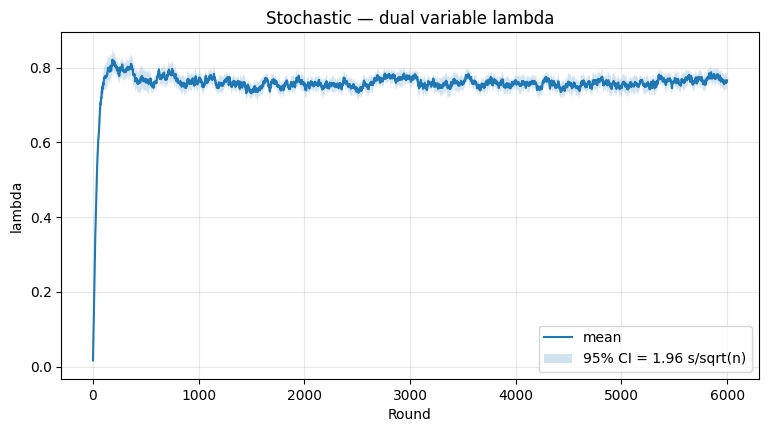

In [53]:

plot_mean_ci(stochastic_runs, "regret", "Stochastic — realized regret, mean ± 1.96 CI", "Cumulative realized regret")
plot_mean_ci(stochastic_runs, "pseudo_regret", "Stochastic — pseudo-regret, mean ± 1.96 CI", "Cumulative pseudo-regret")
plot_mean_ci(stochastic_runs, "cost", "Stochastic — cumulative cost", "Cumulative cost")
plot_mean_ci(stochastic_runs, "lambda", "Stochastic — dual variable lambda", "lambda")



## 11. Test highly non-stationary : many phases


`discount` is a forget parameter, when 1.0, FTPL acts on the whole reward sequence.


In [54]:

NS_PHASES = 80
nonstationary_phases = make_highly_nonstationary_phases(
    T=config.T,
    N=config.N,
    n_phases=NS_PHASES,
    seed=123,
)

nonstationary_learner_cfg = FTPLPrimalDualConfig(
    eta_primal=0.08,
    eta_dual=0.04,
    lambda_max=10.0,
    discount=1.0,
    enforce_hard_budget=True,
)

nonstationary_runs, nonstationary_actions, nonstationary_benchmarks = run_experiment(
    scenario_name="highly non-stationary",
    config=config,
    phases=nonstationary_phases,
    learner_config=nonstationary_learner_cfg,
    n_runs=N_RUNS,
    seed0=1_000,
)

summarize_final_metrics(nonstationary_runs, config, scenario="highly non-stationary")


highly non-stationary: 211 feasible actions, 80 phase(s), rho=0.400
Benchmark expected cost range: [0.4, 0.4, 0.4, 0.4, 0.4] ...


,scenario,final_reward,final_cost,budget_used_%,final_regret,final_pseudo_regret,final_lambda
mean,highly non-stationary,4424.292500,2.400000e+03,1.000000e+02,2553.744002,2555.666293,0.549400
std,highly non-stationary,19.284622,4.473879e-12,1.858882e-13,27.666748,16.374371,0.138082
ci_95_halfwidth,highly non-stationary,8.451858,1.960764e-12,8.146911e-14,12.125487,7.176384,0.060517


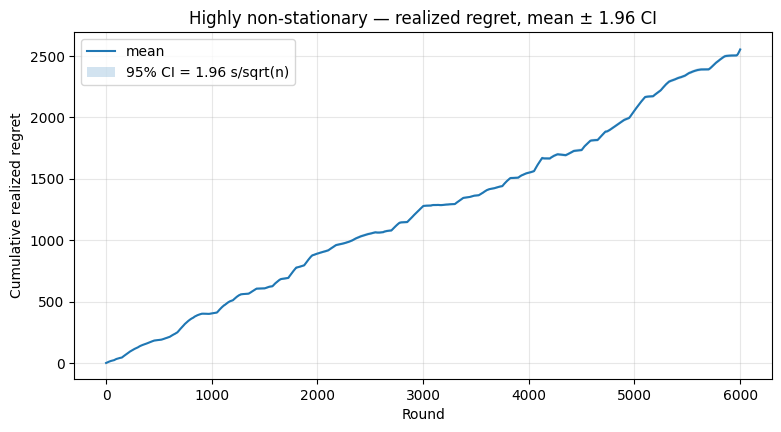

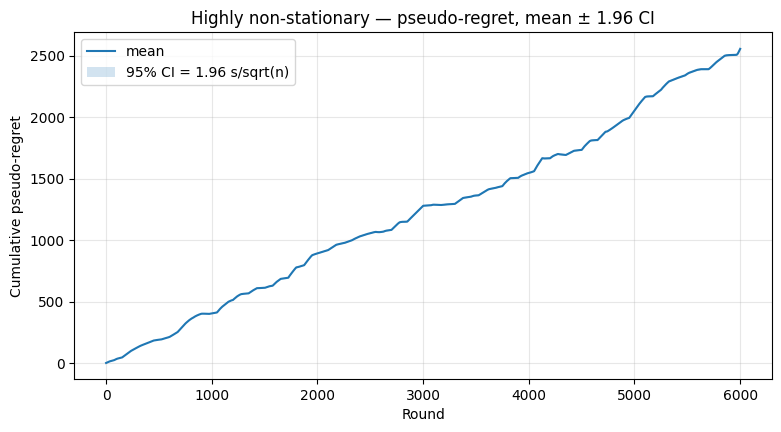

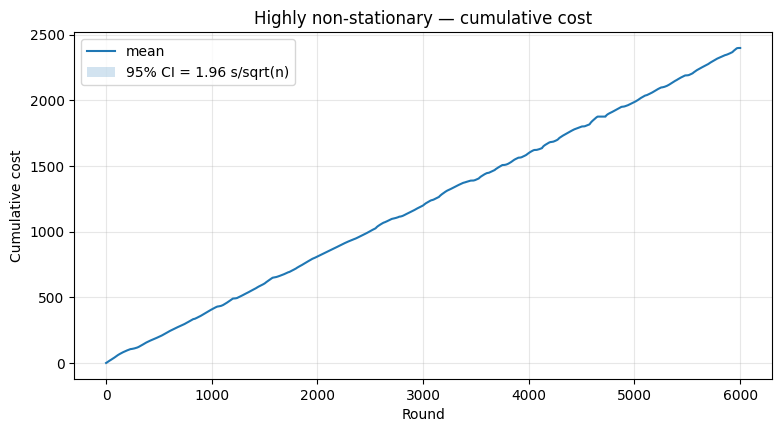

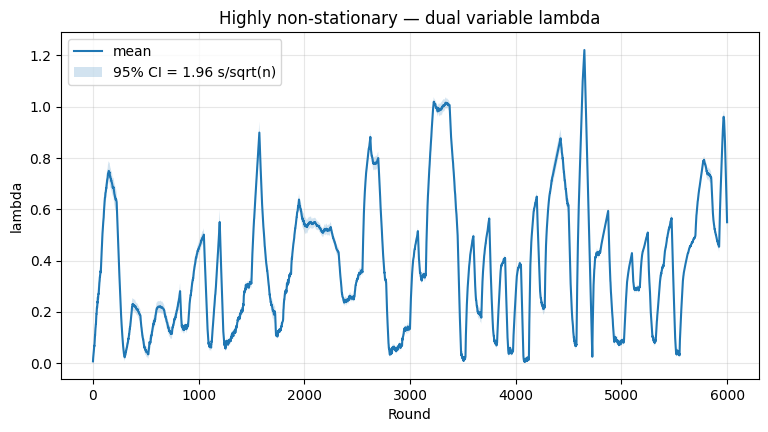

In [55]:

plot_mean_ci(nonstationary_runs, "regret", "Highly non-stationary — realized regret, mean ± 1.96 CI", "Cumulative realized regret")
plot_mean_ci(nonstationary_runs, "pseudo_regret", "Highly non-stationary — pseudo-regret, mean ± 1.96 CI", "Cumulative pseudo-regret")
plot_mean_ci(nonstationary_runs, "cost", "Highly non-stationary — cumulative cost", "Cumulative cost")
plot_mean_ci(nonstationary_runs, "lambda", "Highly non-stationary — dual variable lambda", "lambda")


## 12. Final comparison between the two scenarios

In [56]:

summary = pd.concat(
    [
        summarize_final_metrics(stochastic_runs, config, scenario="stochastic"),
        summarize_final_metrics(nonstationary_runs, config, scenario="highly non-stationary"),
    ],
    axis=0,
)
summary


,scenario,final_reward,final_cost,budget_used_%,final_regret,final_pseudo_regret,final_lambda
mean,stochastic,4868.735000,2.418967e+03,1.007903e+02,60.541354,60.740820,0.765700
std,stochastic,31.900702,1.206373e+00,5.026554e-02,17.507250,14.218301,0.044287
ci_95_halfwidth,stochastic,13.981099,5.287162e-01,2.202984e-02,7.672890,6.231445,0.019410
mean,highly non-stationary,4424.292500,2.400000e+03,1.000000e+02,2553.744002,2555.666293,0.549400
std,highly non-stationary,19.284622,4.473879e-12,1.858882e-13,27.666748,16.374371,0.138082
ci_95_halfwidth,highly non-stationary,8.451858,1.960764e-12,8.146911e-14,12.125487,7.176384,0.060517


### Benchmark best global distribution in hindsight

In [57]:
# ============================================================
# Highly non-stationary — regret vs best distribution in hindsight
# ============================================================
#
# This cell keeps the same learner trajectories as nonstationary_runs.
# It only changes the benchmark:
#
#   phase-wise oracle        : one best distribution per phase
#   hindsight oracle here    : one fixed distribution over all T rounds
#
# The hindsight distribution is chosen after seeing all phase distributions,
# under the global expected budget constraint:
#
#   sum_t E_pi[c_t(a)] <= B
#
# Equivalently:
#
#   (1/T) sum_t E_pi[c_t(a)] <= rho


@dataclass
class HindsightBenchmark:
    p_opt: np.ndarray
    total_value: float
    total_expected_cost: float
    expected_reward_per_round: np.ndarray
    expected_cost_per_round: np.ndarray
    exp_rewards_all_t: np.ndarray
    exp_costs_all_t: np.ndarray


def compute_hindsight_benchmark(
    config: ProblemConfig,
    actions: np.ndarray,
    phases: list[BetaPhase],
) -> HindsightBenchmark:
    T = config.T
    A = len(actions)

    exp_rewards_all_t = np.zeros((T, A))
    exp_costs_all_t = np.zeros((T, A))

    for phase in phases:
        exp_rewards, exp_costs = expected_reward_cost_all(
            actions=actions,
            values=config.values,
            alpha=phase.alpha,
            beta=phase.beta,
            max_bid=config.max_bid,
        )

        exp_rewards_all_t[phase.start:phase.end, :] = exp_rewards[None, :]
        exp_costs_all_t[phase.start:phase.end, :] = exp_costs[None, :]

    total_rewards = exp_rewards_all_t.sum(axis=0)
    total_costs = exp_costs_all_t.sum(axis=0)

    res = linprog(
        c=-total_rewards,
        A_ub=total_costs[None, :],
        b_ub=np.array([config.budget]),
        A_eq=np.ones((1, A)),
        b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * A,
        method="highs",
    )

    if not res.success:
        raise RuntimeError(res.message)

    p_opt = np.maximum(res.x, 0.0)
    p_opt = p_opt / p_opt.sum()

    expected_reward_per_round = exp_rewards_all_t @ p_opt
    expected_cost_per_round = exp_costs_all_t @ p_opt

    return HindsightBenchmark(
        p_opt=p_opt,
        total_value=float(total_rewards @ p_opt),
        total_expected_cost=float(total_costs @ p_opt),
        expected_reward_per_round=expected_reward_per_round,
        expected_cost_per_round=expected_cost_per_round,
        exp_rewards_all_t=exp_rewards_all_t,
        exp_costs_all_t=exp_costs_all_t,
    )


def recompute_runs_against_hindsight(
    runs: list[dict],
    config: ProblemConfig,
    actions: np.ndarray,
    phases: list[BetaPhase],
    learner_config: FTPLPrimalDualConfig,
    seed0: int,
) -> tuple[list[dict], HindsightBenchmark]:
    """
    Re-runs the same non-stationary experiment with the same seeds,
    but computes regret and pseudo-regret against a single hindsight
    distribution over all feasible actions.
    """

    hindsight = compute_hindsight_benchmark(
        config=config,
        actions=actions,
        phases=phases,
    )

    hindsight_runs = []

    for k in range(len(runs)):
        seed = seed0 + k

        env = BetaPhaseEnvironment(
            config=config,
            phases=phases,
            seed=10_000 + seed,
        )

        learner = FTPLPrimalDualBidder(
            actions=actions,
            config=config,
            learner_config=learner_config,
            seed=seed,
        )

        T = config.T

        out = {
            "reward": np.zeros(T),
            "cost": np.zeros(T),
            "lambda": np.zeros(T),
            "remaining_budget": np.zeros(T),
            "regret": np.zeros(T),
            "pseudo_regret": np.zeros(T),
            "oracle_realized_reward": np.zeros(T),
            "oracle_expected_reward": np.zeros(T),
            "learner_expected_reward": np.zeros(T),
        }

        cum_reward = 0.0
        cum_cost = 0.0
        cum_regret = 0.0
        cum_pseudo_regret = 0.0

        for t in range(T):
            action_id = learner.choose_action()
            m_t, _ = env.get_round(t)

            rewards_all, costs_all = realized_reward_cost_all(
                actions,
                m_t,
                config.values,
            )

            oracle_realized_reward_t = float(hindsight.p_opt @ rewards_all)
            oracle_expected_reward_t = float(hindsight.expected_reward_per_round[t])
            learner_expected_reward_t = float(
                hindsight.exp_rewards_all_t[t, action_id]
            )

            reward_t, cost_t = learner.update(
                rewards_all,
                costs_all,
                action_id,
            )

            cum_reward += reward_t
            cum_cost += cost_t
            cum_regret += oracle_realized_reward_t - reward_t
            cum_pseudo_regret += (
                oracle_expected_reward_t - learner_expected_reward_t
            )

            out["reward"][t] = cum_reward
            out["cost"][t] = cum_cost
            out["lambda"][t] = learner.lambda_dual
            out["remaining_budget"][t] = learner.remaining_budget
            out["regret"][t] = cum_regret
            out["pseudo_regret"][t] = cum_pseudo_regret
            out["oracle_realized_reward"][t] = oracle_realized_reward_t
            out["oracle_expected_reward"][t] = oracle_expected_reward_t
            out["learner_expected_reward"][t] = learner_expected_reward_t

        out["final_reward"] = float(out["reward"][-1])
        out["final_cost"] = float(out["cost"][-1])
        out["final_regret"] = float(out["regret"][-1])
        out["final_pseudo_regret"] = float(out["pseudo_regret"][-1])
        out["final_lambda"] = float(out["lambda"][-1])

        hindsight_runs.append(out)

    return hindsight_runs, hindsight


nonstationary_hindsight_runs, nonstationary_hindsight_benchmark = (
    recompute_runs_against_hindsight(
        runs=nonstationary_runs,
        config=config,
        actions=nonstationary_actions,
        phases=nonstationary_phases,
        learner_config=nonstationary_learner_cfg,
        seed0=1_000,
    )
)

print("Hindsight benchmark expected total reward:",
      round(nonstationary_hindsight_benchmark.total_value, 3))

print("Hindsight benchmark expected total cost:",
      round(nonstationary_hindsight_benchmark.total_expected_cost, 3),
      "/ budget:",
      round(config.budget, 3))

summarize_final_metrics(
    nonstationary_hindsight_runs,
    config,
    scenario="highly non-stationary — hindsight benchmark",
)

Hindsight benchmark expected total reward: 4363.999
Hindsight benchmark expected total cost: 2400.0 / budget: 2400.0


,scenario,final_reward,final_cost,budget_used_%,final_regret,final_pseudo_regret,final_lambda
mean,highly non-stationary — hindsight benchmark,4424.292500,2.400000e+03,1.000000e+02,-65.941929,-59.822625,0.549400
std,highly non-stationary — hindsight benchmark,19.284622,4.473879e-12,1.858882e-13,17.991449,16.374371,0.138082
ci_95_halfwidth,highly non-stationary — hindsight benchmark,8.451858,1.960764e-12,8.146911e-14,7.885100,7.176384,0.060517


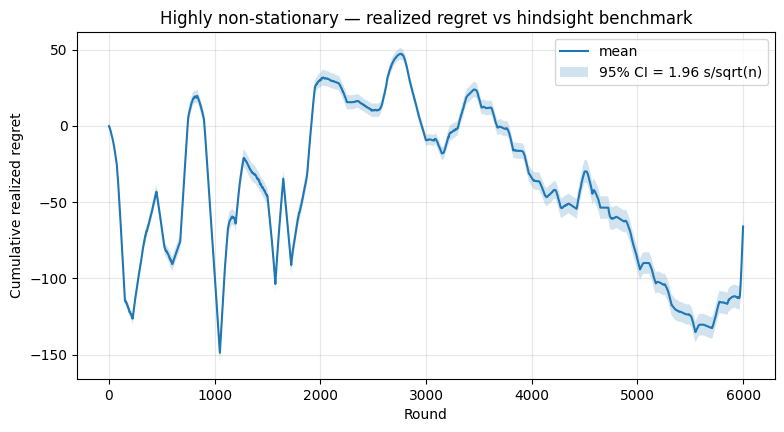

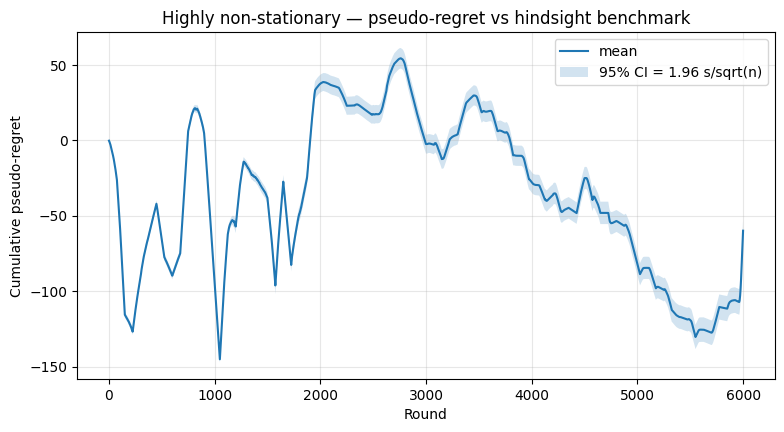

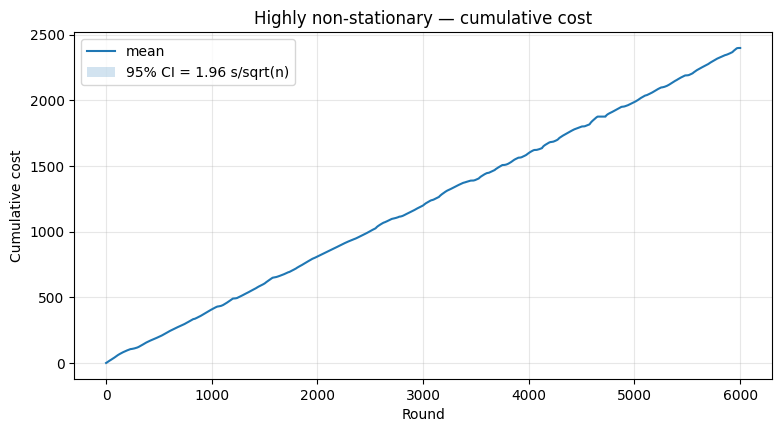

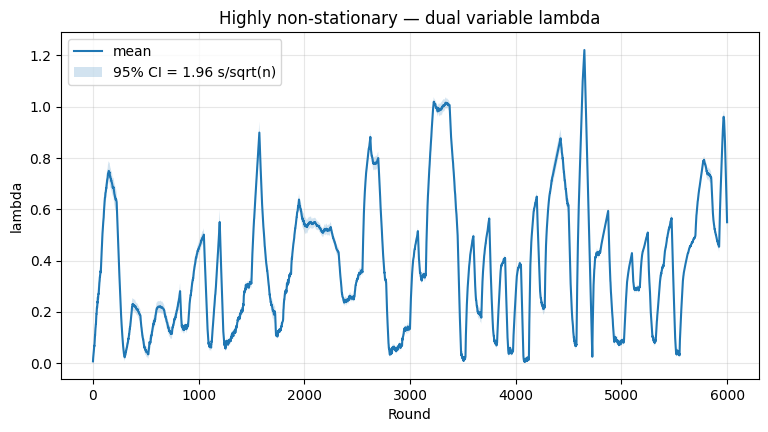

In [58]:
plot_mean_ci(
    nonstationary_hindsight_runs,
    "regret",
    "Highly non-stationary — realized regret vs hindsight benchmark",
    "Cumulative realized regret",
)

plot_mean_ci(
    nonstationary_hindsight_runs,
    "pseudo_regret",
    "Highly non-stationary — pseudo-regret vs hindsight benchmark",
    "Cumulative pseudo-regret",
)

plot_mean_ci(
    nonstationary_hindsight_runs,
    "cost",
    "Highly non-stationary — cumulative cost",
    "Cumulative cost",
)

plot_mean_ci(
    nonstationary_hindsight_runs,
    "lambda",
    "Highly non-stationary — dual variable lambda",
    "lambda",
)

### Benchmark block-wise


In [59]:
# ============================================================
# Highly non-stationary — block-wise hindsight benchmark
# ============================================================
#
# Benchmark intermédiaire :
# - une distribution fixe par bloc temporel ;
# - pas une distribution par phase ;
# - pas une seule distribution globale.
#
# block_size = T        -> hindsight global
# block_size ~= phase length -> proche phase-wise oracle
#
# À tester : 250, 500, 1000 selon T.

BLOCK_SIZE = 500


@dataclass
class BlockWiseBenchmark:
    block_id_per_t: np.ndarray
    p_opts: list
    block_values: np.ndarray
    block_expected_costs: np.ndarray
    expected_reward_per_round: np.ndarray
    expected_cost_per_round: np.ndarray
    exp_rewards_all_t: np.ndarray
    exp_costs_all_t: np.ndarray


def compute_blockwise_hindsight_benchmark(
    config: ProblemConfig,
    actions: np.ndarray,
    phases: list[BetaPhase],
    block_size: int,
) -> BlockWiseBenchmark:
    T = config.T
    A = len(actions)

    exp_rewards_all_t = np.zeros((T, A))
    exp_costs_all_t = np.zeros((T, A))

    # Expected reward/cost of every action at every round,
    # using the distribution of the current phase.
    for phase in phases:
        exp_rewards, exp_costs = expected_reward_cost_all(
            actions=actions,
            values=config.values,
            alpha=phase.alpha,
            beta=phase.beta,
            max_bid=config.max_bid,
        )

        exp_rewards_all_t[phase.start:phase.end, :] = exp_rewards[None, :]
        exp_costs_all_t[phase.start:phase.end, :] = exp_costs[None, :]

    n_blocks = int(np.ceil(T / block_size))
    block_id_per_t = np.zeros(T, dtype=int)

    p_opts = []
    block_values = np.zeros(n_blocks)
    block_expected_costs = np.zeros(n_blocks)

    expected_reward_per_round = np.zeros(T)
    expected_cost_per_round = np.zeros(T)

    for b in range(n_blocks):
        start = b * block_size
        end = min(T, (b + 1) * block_size)
        block_id_per_t[start:end] = b

        block_rewards = exp_rewards_all_t[start:end, :].sum(axis=0)
        block_costs = exp_costs_all_t[start:end, :].sum(axis=0)

        block_budget = config.rho * (end - start)

        res = linprog(
            c=-block_rewards,
            A_ub=block_costs[None, :],
            b_ub=np.array([block_budget]),
            A_eq=np.ones((1, A)),
            b_eq=np.array([1.0]),
            bounds=[(0.0, 1.0)] * A,
            method="highs",
        )

        if not res.success:
            raise RuntimeError(res.message)

        p_opt = np.maximum(res.x, 0.0)
        p_opt = p_opt / p_opt.sum()

        p_opts.append(p_opt)

        block_values[b] = float(block_rewards @ p_opt)
        block_expected_costs[b] = float(block_costs @ p_opt)

        expected_reward_per_round[start:end] = exp_rewards_all_t[start:end, :] @ p_opt
        expected_cost_per_round[start:end] = exp_costs_all_t[start:end, :] @ p_opt

    return BlockWiseBenchmark(
        block_id_per_t=block_id_per_t,
        p_opts=p_opts,
        block_values=block_values,
        block_expected_costs=block_expected_costs,
        expected_reward_per_round=expected_reward_per_round,
        expected_cost_per_round=expected_cost_per_round,
        exp_rewards_all_t=exp_rewards_all_t,
        exp_costs_all_t=exp_costs_all_t,
    )


def run_one_seed_blockwise_hindsight(
    config: ProblemConfig,
    actions: np.ndarray,
    phases: list[BetaPhase],
    learner_config: FTPLPrimalDualConfig,
    block_benchmark: BlockWiseBenchmark,
    seed: int,
):
    env = BetaPhaseEnvironment(
        config=config,
        phases=phases,
        seed=10_000 + seed,
    )

    learner = FTPLPrimalDualBidder(
        actions=actions,
        config=config,
        learner_config=learner_config,
        seed=seed,
    )

    T = config.T

    out = {
        "reward": np.zeros(T),
        "cost": np.zeros(T),
        "lambda": np.zeros(T),
        "remaining_budget": np.zeros(T),
        "regret": np.zeros(T),
        "pseudo_regret": np.zeros(T),
        "oracle_expected_reward": np.zeros(T),
        "learner_expected_reward": np.zeros(T),
    }

    cum_reward = 0.0
    cum_cost = 0.0
    cum_regret = 0.0
    cum_pseudo_regret = 0.0

    for t in range(T):
        action_id = learner.choose_action()
        m_t, _ = env.get_round(t)

        rewards_all, costs_all = realized_reward_cost_all(
            actions,
            m_t,
            config.values,
        )

        b = block_benchmark.block_id_per_t[t]
        p_block = block_benchmark.p_opts[b]

        oracle_realized_reward_t = float(p_block @ rewards_all)
        oracle_expected_reward_t = float(
            block_benchmark.expected_reward_per_round[t]
        )
        learner_expected_reward_t = float(
            block_benchmark.exp_rewards_all_t[t, action_id]
        )

        reward_t, cost_t = learner.update(
            rewards_all,
            costs_all,
            action_id,
        )

        cum_reward += reward_t
        cum_cost += cost_t
        cum_regret += oracle_realized_reward_t - reward_t
        cum_pseudo_regret += oracle_expected_reward_t - learner_expected_reward_t

        out["reward"][t] = cum_reward
        out["cost"][t] = cum_cost
        out["lambda"][t] = learner.lambda_dual
        out["remaining_budget"][t] = learner.remaining_budget
        out["regret"][t] = cum_regret
        out["pseudo_regret"][t] = cum_pseudo_regret
        out["oracle_expected_reward"][t] = oracle_expected_reward_t
        out["learner_expected_reward"][t] = learner_expected_reward_t

    out["final_reward"] = float(out["reward"][-1])
    out["final_cost"] = float(out["cost"][-1])
    out["final_regret"] = float(out["regret"][-1])
    out["final_pseudo_regret"] = float(out["pseudo_regret"][-1])
    out["final_lambda"] = float(out["lambda"][-1])

    return out


def run_blockwise_hindsight_experiment(
    config: ProblemConfig,
    actions: np.ndarray,
    phases: list[BetaPhase],
    learner_config: FTPLPrimalDualConfig,
    block_size: int,
    n_runs: int,
    seed0: int,
):
    block_benchmark = compute_blockwise_hindsight_benchmark(
        config=config,
        actions=actions,
        phases=phases,
        block_size=block_size,
    )

    runs = []

    for k in range(n_runs):
        runs.append(
            run_one_seed_blockwise_hindsight(
                config=config,
                actions=actions,
                phases=phases,
                learner_config=learner_config,
                block_benchmark=block_benchmark,
                seed=seed0 + k,
            )
        )

    return runs, block_benchmark


nonstationary_blockwise_runs, nonstationary_blockwise_benchmark = (
    run_blockwise_hindsight_experiment(
        config=config,
        actions=nonstationary_actions,
        phases=nonstationary_phases,
        learner_config=nonstationary_learner_cfg,
        block_size=BLOCK_SIZE,
        n_runs=len(nonstationary_runs),
        seed0=1_000,
    )
)

print("Block size:", BLOCK_SIZE)
print("Number of blocks:", len(nonstationary_blockwise_benchmark.p_opts))
print(
    "Block-wise benchmark expected total reward:",
    round(nonstationary_blockwise_benchmark.block_values.sum(), 3),
)
print(
    "Block-wise benchmark expected total cost:",
    round(nonstationary_blockwise_benchmark.block_expected_costs.sum(), 3),
    "/ budget:",
    round(config.budget, 3),
)

summarize_final_metrics(
    nonstationary_blockwise_runs,
    config,
    scenario=f"highly non-stationary — block-wise hindsight, block_size={BLOCK_SIZE}",
)

Block size: 500
Number of blocks: 12
Block-wise benchmark expected total reward: 4880.687
Block-wise benchmark expected total cost: 2400.0 / budget: 2400.0


,scenario,final_reward,final_cost,budget_used_%,final_regret,final_pseudo_regret,final_lambda
mean,"highly non-stationary — block-wise hindsight, ...",4424.292500,2.400000e+03,1.000000e+02,451.358908,456.865145,0.549400
std,"highly non-stationary — block-wise hindsight, ...",19.284622,4.473879e-12,1.858882e-13,22.995089,16.374371,0.138082
ci_95_halfwidth,"highly non-stationary — block-wise hindsight, ...",8.451858,1.960764e-12,8.146911e-14,10.078042,7.176384,0.060517


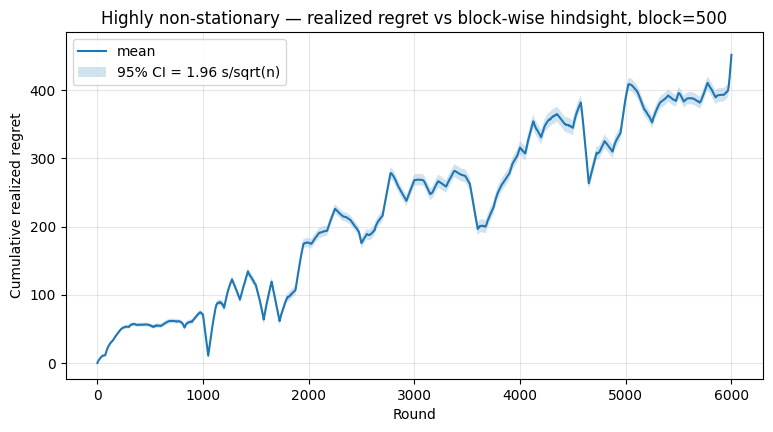

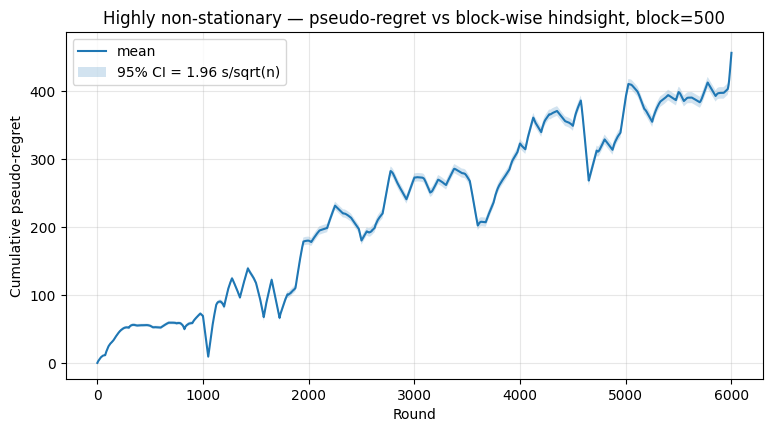

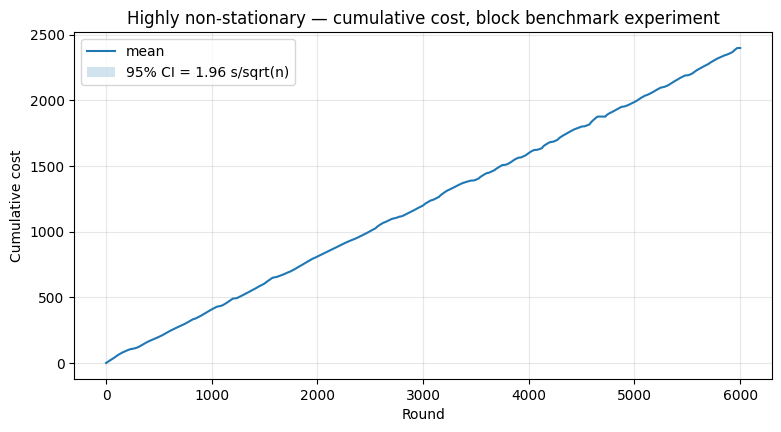

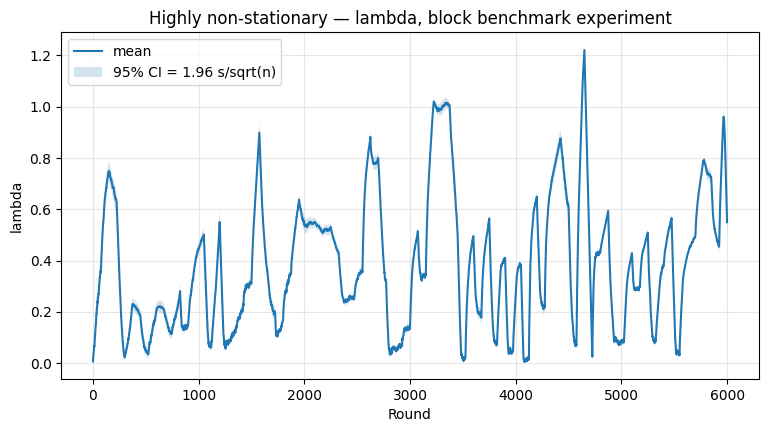

In [60]:
plot_mean_ci(
    nonstationary_blockwise_runs,
    "regret",
    f"Highly non-stationary — realized regret vs block-wise hindsight, block={BLOCK_SIZE}",
    "Cumulative realized regret",
)

plot_mean_ci(
    nonstationary_blockwise_runs,
    "pseudo_regret",
    f"Highly non-stationary — pseudo-regret vs block-wise hindsight, block={BLOCK_SIZE}",
    "Cumulative pseudo-regret",
)

plot_mean_ci(
    nonstationary_blockwise_runs,
    "cost",
    f"Highly non-stationary — cumulative cost, block benchmark experiment",
    "Cumulative cost",
)

plot_mean_ci(
    nonstationary_blockwise_runs,
    "lambda",
    f"Highly non-stationary — lambda, block benchmark experiment",
    "lambda",
)